![Health-Informatics: A Python Tutorial](../../Image/chapter-banner.png)


# Module 2: Health Data Types and Structure



**Health Informatics in Python** · Part I: Foundations · Module 2 of 16

---

Before you can standardize, exchange, or analyze health data, you have to
understand its **shape**. This module dissects the core entities of an EHR and
the difference between structured, unstructured, and semi-structured data.


## Learning objectives

By the end of this module you will be able to:

1. Distinguish **structured, unstructured, and semi-structured** clinical data.
2. Identify the **core clinical entities**: patients, encounters, observations,
   conditions, medications, procedures.
3. Work with **longitudinal, time-stamped** data.
4. Join the EHR tables into an **analysis-ready** patient view.
5. Reshape observations between **long and wide** formats.


## Dataset

We reuse the synthetic EHR from Module 1 — same generator, same seed — so the
relational structure is identical. We add a small block of free-text clinical
notes to illustrate unstructured data.


In [1]:
# --- Self-contained synthetic EHR generator (no external downloads) ---
# This is the SAME generator from Module 1. We rebuild the fake hospital database
# here so this notebook can run on its own. Nothing here is a real patient.
import numpy as np
import pandas as pd

# This function generates a synthetic electronic health record (EHR) dataset.
# It creates mock tables for patients, encounters, observations, conditions, and medications,
# all with plausible structure, but not referencing any real patients or requiring external data.
def make_synthetic_ehr(n_patients=200, seed=42):
    """
    Generate a small, internally-consistent synthetic EHR dataset.
    Returns a dict of linked DataFrames: patients, encounters, observations,
    conditions, and medications. This is for illustrative, educational use.
    """
    rng = np.random.default_rng(seed)  # Ensures reproducibility: same seed => same fake people

    # --- patients table ---
    # Create a DataFrame with n_patients patients, each with a name, sex, age, and calculated birth_year.
    first = ["Ava","Liam","Noah","Mia","Zoe","Omar","Ivan","Sara","Leo","Nina",
             "Ruth","Kai","Yara","Theo","Ida","Sam","Ana","Eli","Rex","Uma"]
    last  = ["Khan","Ortiz","Chen","Diaz","Patel","Ali","Brown","Nash","Reed","Vega",
             "Cole","Frost","Grant","Hale","Iqbal","Jain","Kerr","Lund","Mora","Park"]
    sexes = rng.choice(["male", "female"], size=n_patients, p=[0.49, 0.51])
    ages  = rng.integers(18, 90, size=n_patients)
    # This block creates a DataFrame called 'patients' with columns representing patient attributes.
    # - "patient_id": Assigns a unique ID to each patient, e.g., "P1000", "P1001", etc.
    # - "given_name": Randomly selects one of the first names for each patient.
    # - "family_name": Randomly selects one of the last names for each patient.
    # - "sex": The pre-generated array of male/female assignments.
    # - "age": The pre-generated ages for each patient.
    # - "birth_year": Calculates the year of birth based on the age, assuming a reference year of 2026.
    patients = pd.DataFrame({
        "patient_id": [f"P{1000+i}" for i in range(n_patients)],
        "given_name": rng.choice(first, size=n_patients),
        "family_name": rng.choice(last, size=n_patients),
        "sex": sexes,
        "age": ages,
        "birth_year": 2026 - ages,
    })

    # --- encounters table ---
    # The following block generates synthetic 'encounters' for each patient:
    # - Each patient has between 1 and 4 encounters (randomly chosen).
    # - Each encounter is assigned a type: 'ambulatory', 'emergency', 'inpatient', or 'wellness'.
    #   The probability of each type is respectively: 55% ambulatory, 15% emergency, 10% inpatient, and 20% wellness.
    # - The encounter's date is randomly set within a 3-year window starting from Jan 1, 2023.
    # - Each encounter receives:
    #     - A unique encounter_id (e.g., E00001, E00002, ...).
    #     - The associated patient_id.
    #     - The randomly assigned type and date.
    enc_rows = []
    enc_types = ["ambulatory", "emergency", "inpatient", "wellness"]
    for pid in patients["patient_id"]:
        # Randomly determine how many encounters (between 1 and 4) this patient has
        for _ in range(rng.integers(1, 5)):
            # For each encounter, pick a random day offset within 3 years (0 to 1094)
            day = rng.integers(0, 365*3)
            enc_rows.append({
                "encounter_id": f"E{len(enc_rows)+1:05d}",
                "patient_id": pid,
                # Assign encounter type with the specified probabilities
                "encounter_type": rng.choice(enc_types, p=[0.55, 0.15, 0.10, 0.20]),
                # Calculate the date of the encounter by adding day offset to Jan 1, 2023
                "date": (pd.Timestamp("2023-01-01") + pd.Timedelta(days=int(day))).date(),
            })
    # Assemble all rows into a DataFrame
    encounters = pd.DataFrame(enc_rows)

    # --- observations table ---
    # This block generates synthetic laboratory and vital sign results ("observations") for each encounter.
    #
    # 1. Define a set of different types of observations (e.g., height, blood pressure) with:
    #    - A human-readable name
    #    - The unit of measurement
    #    - A plausible lower and upper bound for values (lo, hi)
    obs_defs = [
        ("Body height", "cm", 150, 195),
        ("Body weight", "kg", 50, 110),
        ("Systolic blood pressure", "mmHg", 100, 165),
        ("Heart rate", "/min", 55, 100),
        ("Hemoglobin A1c", "%", 4.8, 9.5),
    ]
    obs_rows = []
    # 2. For every encounter (row in the encounters DataFrame):
    for _, e in encounters.iterrows():
        # 3. For each defined observation type, with 70% probability:
        for name, unit, lo, hi in obs_defs:
            if rng.random() < 0.7:  # 70% chance this observation is present in this encounter
                # 4. Generate a random value within the allowed range, rounded to 1 decimal.
                val = round(float(rng.uniform(lo, hi)), 1)
                # 5. Assemble observation fields:
                #    - Unique observation_id (zero-padded)
                #    - encounter_id and patient_id (from the current encounter)
                #    - observation name, value, unit, and date (from the encounter)
                obs_rows.append({
                    "observation_id": f"O{len(obs_rows)+1:06d}",
                    "encounter_id": e["encounter_id"],
                    "patient_id": e["patient_id"],
                    "observation": name,
                    "value": val,
                    "unit": unit,
                    "date": e["date"],
                })
    # 6. Create a DataFrame (table) of all generated observations
    observations = pd.DataFrame(obs_rows)

    # --- conditions table ---
    # This block generates a table of medical conditions (diagnoses) assigned to each patient.
    #
    # Steps:
    # 1. Define a list of possible conditions (diagnoses) that a patient might have, called cond_pool.
    cond_pool = ["Essential hypertension", "Type 2 diabetes mellitus", "Asthma",
                 "Acute bronchitis", "Major depressive disorder", "Osteoarthritis",
                 "Chronic kidney disease", "Anemia"]
    cond_rows = []
    # 2. For every patient, randomly assign them between 0 and 3 unique conditions from the pool.
    for pid in patients["patient_id"]:
        # rng.integers(0, 4) generates the number of conditions to assign (0–3),
        # and rng.choice picks that many unique conditions for that patient.
        for c in rng.choice(cond_pool, size=rng.integers(0, 4), replace=False):
            # 3. For each assigned condition, create a dictionary with:
            #   - a unique condition_id (zero-padded)
            #   - the patient_id
            #   - the condition name
            cond_rows.append({
                "condition_id": f"C{len(cond_rows)+1:05d}",
                "patient_id": pid,
                "condition": c,
            })
    # 4. Assemble all condition records into a DataFrame.
    conditions = pd.DataFrame(cond_rows)

    # --- medications table ---
    # This section generates a medications table, which records what medications each patient is taking.
    #
    # Steps:
    # 1. Define a list of possible medications, called med_pool, that could be assigned to any patient.
    med_pool = ["Lisinopril", "Metformin", "Albuterol", "Atorvastatin",
                "Sertraline", "Amoxicillin", "Ibuprofen", "Hydrochlorothiazide"]
    med_rows = []
    # 2. For each patient in the patients DataFrame:
    for pid in patients["patient_id"]:
        # Randomly assign between 0 and 3 different medications to the patient.
        # rng.integers(0, 4) picks how many meds the patient will get (can be zero).
        # rng.choice picks the medicines without replacement.
        for m in rng.choice(med_pool, size=rng.integers(0, 4), replace=False):
            # 3. For each assigned medication, create a dictionary that includes:
            #   - Unique medication_id (zero-padded)
            #   - patient_id
            #   - medication name
            med_rows.append({
                "medication_id": f"M{len(med_rows)+1:05d}",
                "patient_id": pid,
                "medication": m,
            })
    # 4. Assemble all medication records into a DataFrame.
    medications = pd.DataFrame(med_rows)

    # Return a dictionary containing all generated synthetic EHR tables.
    return {
        "patients": patients,
        "encounters": encounters,
        "observations": observations,
        "conditions": conditions,
        "medications": medications,
    }

# Generate the synthetic EHR data by calling the make_synthetic_ehr() function.
# This returns a dictionary where each key is a table name (e.g., "patients", "encounters")
# and each value is a pandas DataFrame with the data for that table.
ehr = make_synthetic_ehr()

# Print out the names of each table along with the number of rows it contains,
# to provide a quick overview of the size of each synthetic EHR table.
print("Tables:", ", ".join(f"{k} ({len(v)} rows)" for k, v in ehr.items()))


Tables: patients (200 rows), encounters (511 rows), observations (1804 rows), conditions (304 rows), medications (276 rows)


## 2.1 Three kinds of health data

| Kind | Example | How it's stored | How you work with it |
|---|---|---|---|
| **Structured** | A1c = 7.2 %, coded diagnosis | Rows & columns, coded fields | `pandas`, SQL |
| **Unstructured** | A progress note, radiology report | Free text | NLP (Module 10) |
| **Semi-structured** | HL7 / FHIR / CDA messages | Nested key–value / XML / JSON | Parsers (Module 4) |

Roughly **80% of clinical information** lives in unstructured text — which is why
NLP is such a large part of applied informatics.


In [2]:
# This cell shows the difference between STRUCTURED data and UNSTRUCTURED data.
#
# Structured data lives in tables: every value sits in a named column (patient_id,
# observation, value, unit, date). A computer can count, filter, and join it easily.
#
# Unstructured data is free text — a clinical note. A human can read it, but a
# computer just sees a blob of characters until we use NLP (Module 10).

print("STRUCTURED — observations table:")
# Pick a few useful columns so the printout is easy to read
display_cols = ["patient_id", "observation", "value", "unit", "date"]
# ehr["observations"] is the observations DataFrame from the generator above.
# [display_cols] keeps only those five columns.
# .head(4) means "show the first 4 rows".
# .to_string(index=False) prints a clean table without the pandas row numbers.
print(ehr["observations"][display_cols].head(4).to_string(index=False))

print("\nUNSTRUCTURED — a free-text clinical note:")
# A fake progress note, written the way a clinician might type it:
# abbreviations (y/o, h/o, HTN, T2DM), mixed facts, no columns.
note = ("58 y/o with h/o HTN and T2DM presents for routine follow-up. "
        "BP 148/88, denies chest pain. Continue lisinopril; recheck A1c in 3 months.")
print(note)


STRUCTURED — observations table:
patient_id observation  value unit       date
     P1000 Body height  158.5   cm 2025-03-17
     P1000 Body weight   55.8   kg 2025-03-17
     P1000  Heart rate   91.4 /min 2025-03-17
     P1000 Body height  179.3   cm 2023-05-21

UNSTRUCTURED — a free-text clinical note:
58 y/o with h/o HTN and T2DM presents for routine follow-up. BP 148/88, denies chest pain. Continue lisinopril; recheck A1c in 3 months.


## 2.2 The core clinical entities

An EHR is organized around a handful of recurring entities. In our synthetic model:

- **patients** - the person (demographics)
- **encounters** - a contact with the health system (a visit)
- **observations** - measurements: vitals and labs
- **conditions** - diagnoses / problems
- **medications** - drugs prescribed or administered

Real systems add **procedures, allergies, immunizations, orders, and results**,
but these five carry most teaching examples.


In [3]:
# This loop peeks at every EHR table so you can see what each one looks like.
#
# ehr is a dictionary: keys are table names, values are pandas DataFrames.
# For each table we print:
#   - a header with the table name
#   - the first 2 rows (just enough to see the columns and a sample of values)
for name in ["patients", "encounters", "observations", "conditions", "medications"]:
    df = ehr[name]  # pull that table out of the dictionary
    print(f"=== {name} ===")
    print(df.head(2).to_string(index=False))
    print()  # blank line between tables so the output is easier to scan


=== patients ===
patient_id given_name family_name    sex  age  birth_year
     P1000       Yara        Khan female   89        1937
     P1001        Sam       Brown   male   73        1953

=== encounters ===
encounter_id patient_id encounter_type       date
      E00001      P1000       wellness 2025-03-17
      E00002      P1000     ambulatory 2023-05-21

=== observations ===
observation_id encounter_id patient_id observation  value unit       date
       O000001       E00001      P1000 Body height  158.5   cm 2025-03-17
       O000002       E00001      P1000 Body weight   55.8   kg 2025-03-17

=== conditions ===
condition_id patient_id      condition
      C00001      P1000 Osteoarthritis
      C00002      P1000         Anemia

=== medications ===
medication_id patient_id          medication
       M00001      P1000 Hydrochlorothiazide
       M00002      P1000          Sertraline



### Milestone 1 - the encounter as the hub of activity

In an EHR (Electronic Health Record), the encounter acts as the central point or "hub" of clinical activity. Most events—like measurements, diagnoses, orders, and treatments—are linked to a specific visit or encounter, making it the key connector for organizing and analyzing patient data over time.

In [4]:
# This cell treats the encounter as the "hub" of clinical activity:
# almost every measurement, diagnosis, and order hangs off a visit.
#
# Step 1: pull the encounters table out of the ehr dictionary.
enc = ehr["encounters"]

# Step 2: count how many encounters of each type we have.
# value_counts() looks at one column and says "how many times does each value appear?"
# Example output: ambulatory 280, wellness 100, emergency 80, inpatient 51.
print("Encounter types:")
print(enc["encounter_type"].value_counts())
print()

# Step 3: for each patient, count their encounters, then summarize that distribution.
# groupby("patient_id").size() = "how many rows (visits) does each patient have?"
# describe() then gives count / mean / min / max of those per-patient counts.
print("Encounters per patient (distribution):")
print(enc.groupby("patient_id").size().describe().round(2))


Encounter types:
encounter_type
ambulatory    293
wellness      103
emergency      60
inpatient      55
Name: count, dtype: int64

Encounters per patient (distribution):
count    200.00
mean       2.56
std        1.06
min        1.00
25%        2.00
50%        3.00
75%        3.00
max        4.00
dtype: float64


## 2.3 Longitudinal, time-stamped data

Health data is intrinsically tied to time—meaning that many clinical measurements are collected repeatedly for a single patient across different visits or stages of life. This forms a longitudinal record, where values like blood pressure, weight, or lab results are tracked over intervals ranging from days to years. Analyzing these time-stamped data points allows us to observe trends, detect changes (such as improvement or deterioration), and assess how a patient's health evolves rather than relying on just a single measurement. For example, by following one patient’s sequence of blood pressure readings, we can better understand their cardiovascular risk over time or see the effects of a new medication.


In [5]:
# Health data is time-stamped: the SAME measurement (blood pressure) is taken
# again and again. This cell follows ONE patient's systolic BP over time.
#
# .copy() makes a separate copy of the observations table so we can edit it
# without changing the original ehr["observations"] table.
obs = ehr["observations"].copy()

# Dates currently look like 2023-05-12 but they are stored as plain date objects.
# pd.to_datetime() converts them to pandas timestamps so we can sort and plot them.
obs["date"] = pd.to_datetime(obs["date"])

# Keep only the rows where the observation name is "Systolic blood pressure".
# This is a filter: obs["observation"] == "..." is True/False for every row;
# wrapping obs[...] keeps only the True rows.
sbp = obs[obs["observation"] == "Systolic blood pressure"]

# Count how many SBP readings each patient has, then sort highest-first.
# We pick the patient with the MOST readings so the time series is interesting.
counts = sbp.groupby("patient_id").size().sort_values(ascending=False)
pid = counts.index[0]  # the patient_id at the top of that ranked list

# Pull that one patient's SBP rows and sort them by date (oldest -> newest).
track = sbp[sbp["patient_id"] == pid].sort_values("date")
print(f"Patient {pid} — systolic BP over time:")
print(track[["date", "value", "unit"]].to_string(index=False))


Patient P1043 — systolic BP over time:
      date  value unit
2023-01-28  154.0 mmHg
2023-11-24  133.9 mmHg
2025-03-23  155.5 mmHg
2025-12-13  147.3 mmHg


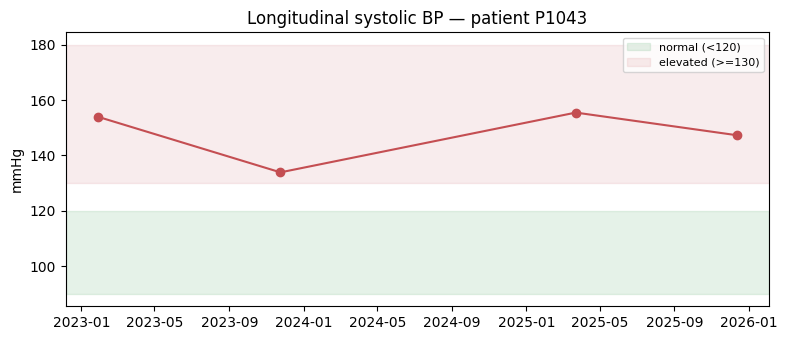

In [6]:
# This code draws a line chart of the one patient's systolic BP over time.
# The shaded bands are a visual reminder of "normal" vs "elevated" ranges —
# they are teaching overlays, not a clinical diagnosis.
import matplotlib.pyplot as plt

# Create one plot (1 figure, 1 set of axes) of a given width and height in inches
fig, ax = plt.subplots(figsize=(8, 3.5))

# Plot date on the x-axis and BP value on the y-axis.
# marker="o" puts a dot on each reading so you can see individual visits.
ax.plot(track["date"], track["value"], marker="o", color="#C44E52")

# axhspan draws a horizontal shaded band between two y-values.
# Green band: roughly "normal" systolic BP (<120).
# Red band: roughly "elevated" (>=130). Alpha makes the bands see-through.
ax.axhspan(90, 120, color="#55A868", alpha=0.15, label="normal (<120)")
ax.axhspan(130, 180, color="#C44E52", alpha=0.10, label="elevated (>=130)")

ax.set_title(f"Longitudinal systolic BP — patient {pid}")
ax.set_ylabel("mmHg")
ax.legend(loc="upper right", fontsize=8)

# tight_layout() stops titles/labels from overlapping; show() displays the figure
plt.tight_layout()
plt.show()


## 2.4 Joining tables into an analysis-ready view

Individual tables answer narrow questions. Real work usually needs them **joined**
around the patient. Below we build a per-patient summary combining demographics,
encounter counts, condition counts, and mean A1c.


In [7]:
# Real analysis rarely uses one table at a time. This cell JOINS several tables
# into one "patient view": one row per patient, with extra summary columns.
#
# Think of a join as: "for this patient_id, go look up extra facts in another table
# and glue them on as new columns."

patients = ehr["patients"]  # the base table: one row per person

# Count encounters per patient, then name that series "n_encounters"
# so it becomes a column with a clear name after the join.
enc_n  = ehr["encounters"].groupby("patient_id").size().rename("n_encounters")

# Same idea for diagnoses: how many condition rows does each patient have?
cond_n = ehr["conditions"].groupby("patient_id").size().rename("n_conditions")

# For A1c: keep only Hemoglobin A1c rows, then average the value per patient.
# round(1) keeps one decimal place (e.g. 7.2).
a1c = (obs[obs["observation"] == "Hemoglobin A1c"]
       .groupby("patient_id")["value"].mean().round(1).rename("mean_a1c"))

# Now glue the summaries onto the patients table.
# how="left" means: keep EVERY patient, even if they have no A1c / no conditions.
# Patients with no match get a missing value (NaN) in that new column.
patient_view = (patients
    .merge(enc_n, on="patient_id", how="left")
    .merge(cond_n, on="patient_id", how="left")
    .merge(a1c, on="patient_id", how="left"))

# Missing encounter/condition counts should mean "zero", not "unknown".
# fillna(0) replaces NaN with 0; astype(int) turns 0.0 into 0.
patient_view[["n_encounters", "n_conditions"]] = (
    patient_view[["n_encounters", "n_conditions"]].fillna(0).astype(int))

# Show the first few rows of the combined view
patient_view.head()


,patient_id,given_name,family_name,sex,age,birth_year,n_encounters,n_conditions,mean_a1c
0,P1000,Yara,Khan,female,89,1937,4,2,8.1
1,P1001,Sam,Brown,male,73,1953,4,1,9.0
2,P1002,Ida,Cole,female,41,1985,1,3,NaN
3,P1003,Noah,Mora,female,87,1939,2,3,5.2
4,P1004,Ana,Iqbal,male,53,1973,3,0,7.0


### Milestone 2 - a simple cohort question

In this section, we demonstrate how to define a simple cohort—a specific group of patients—based on certain criteria in the data.
For example, we can select patients with at least one documented medical condition and a mean Hemoglobin A1c (a key diabetes indicator) of 6.5 or above.
This is known as a "cohort question": identifying which individuals meet a set of rules or clinical thresholds for further study.

In [8]:
# A "cohort" is just a filtered list of patients who meet a rule.
# Here the rule is: mean A1c at or above 6.5 (a common diabetes threshold)
# AND at least one coded condition.
#
# The & means BOTH conditions must be true.
# Parentheses around each comparison are required when combining with &.
cohort = patient_view[(patient_view["mean_a1c"] >= 6.5) &
                      (patient_view["n_conditions"] >= 1)]

# How many people made it through the filter, out of everyone?
print(f"Cohort size: {len(cohort)} of {len(patient_view)} patients")

# Show a few of them, keeping only the columns that explain WHY they qualified
cohort[["patient_id", "age", "sex", "mean_a1c", "n_conditions"]].head()


Cohort size: 95 of 200 patients


,patient_id,age,sex,mean_a1c,n_conditions
0,P1000,89,female,8.1,2
1,P1001,73,male,9.0,1
6,P1006,49,female,8.0,3
9,P1009,19,male,7.4,2
10,P1010,30,male,8.7,3


## 2.5 Long vs. wide format

In the original data, observations are stored in **long** format. This means that each individual measurement
(such as a patient's single blood pressure or heart rate reading) occupies its own row in the table,
identified by the patient, the type of observation, and the recorded value.

However, many analytic tasks and machine learning models require the data in **wide** format, where there is 
only one row per subject (such as a patient or an encounter), and each type of measurement gets its own column.
For example, instead of having many rows for a patient with different tests, we would have a single row for
that patient, with columns for "Body height", "Body weight", "Heart rate", etc.

Converting between these formats is a common and essential skill in data science—often referred to as
"reshaping" or "pivoting" the data. The process of moving from long to wide format is known as "pivoting,"
while moving from wide back to long format is called "melting" or "unpivoting."


In [9]:
# Long -> wide: mean value per patient per observation type
wide = (obs.pivot_table(index="patient_id",
                        columns="observation",
                        values="value",
                        aggfunc="mean")
          .round(1))
print("WIDE format (one row per patient):")
wide.head()

WIDE format (one row per patient):


observation,Body height,Body weight,Heart rate,Hemoglobin A1c,Systolic blood pressure
patient_id,,,,,
P1000,163.5,74.0,81.7,8.1,140.5
P1001,169.7,77.2,94.2,9.0,109.0
P1002,151.6,62.3,78.2,NaN,NaN
P1003,178.2,75.4,80.6,5.2,130.1
P1004,169.7,93.3,60.3,7.0,147.4


In [10]:
# This cell does the reverse reshape: WIDE -> LONG.
#
# reset_index() turns patient_id from an index back into a normal column,
# which melt needs.
#
# melt "unpivots" the table:
#   id_vars    = columns to leave as-is (patient_id)
#   var_name   = name for the column that will hold the old column headers
#                (those observation names become values in a column called "observation")
#   value_name = name for the column that will hold the numbers
#
# dropna() drops rows where the value is missing — a patient who never had
# a height recorded should not get a blank height row in the long table.
long_again = (wide.reset_index()
                  .melt(id_vars="patient_id",
                        var_name="observation",
                        value_name="mean_value")
                  .dropna())
print("LONG format (one row per patient-observation):")
long_again.head()


LONG format (one row per patient-observation):


,patient_id,observation,mean_value
0,P1000,Body height,163.5
1,P1001,Body height,169.7
2,P1002,Body height,151.6
3,P1003,Body height,178.2
4,P1004,Body height,169.7


## Exercises

1. Build an **encounter-level** wide table (index = `encounter_id`) instead of
   patient-level, and note why the missingness pattern changes.
2. For each patient, compute the **time span** between first and last encounter.
3. Flag patients whose systolic BP **increased** across their readings (a naive
   trend feature) and count them.



## Key takeaways

- Health data comes **structured, unstructured, and semi-structured** — each needs
  a different tool.
- The EHR is a **relational model** hubbed on encounters and linked by patient.
- Health data is **longitudinal**; reshaping **long ↔ wide** is routine.



---
*Next: Module 3 - Clinical Terminologies and Coding Systems.*
